# ML Assignment 1: Bike Sharing Demand Prediction

**Objective:** Predict hourly bike rental demand (`count`) using weather, time and seasonal information.  
**Evaluation metric:** Root Mean Squared Logarithmic Error (RMSLE).

This notebook addresses **Q1–Q12**, compares Linear Regression with Ridge/Lasso and a degree-2 polynomial Ridge model, performs residual analysis, and creates the required `submission.csv`.

> **Note:** The training data contains `casual` and `registered`, which sum to `count`. These two columns are target-derived and are therefore **not used as predictors**, because they would not be available in the supplied test set.


In [ ]:
!pip install -r requirements.txt

In [1]:
# Imports and data loading
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_log_error

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

# Works both in this environment and when the notebook is placed beside the CSV files.
DATA_DIR = Path.cwd()
if not (DATA_DIR / "bike_train.csv").exists():
    DATA_DIR = Path("/mnt/data")

train_raw = pd.read_csv(DATA_DIR / "bike_train.csv")
test_raw = pd.read_csv(DATA_DIR / "bike_test.csv")
sample = pd.read_csv(DATA_DIR / "SampleSubmission.csv")

print("Training shape:", train_raw.shape)
print("Test shape:", test_raw.shape)
print("Sample submission shape:", sample.shape)
print("Training columns:", list(train_raw.columns))
print("Test columns:", list(test_raw.columns))


Training shape: (10450, 12)
Test shape: (2613, 9)
Sample submission shape: (2613, 2)
Training columns: ['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']
Test columns: ['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed']


In [2]:
# Q1. Dataset size, missing values and feature types

print("Q1: TRAINING DATA INFORMATION")
print("=" * 60)
print("Shape:", train_raw.shape)
print("\nData types:")
print(train_raw.dtypes)
print("\nMissing values:")
print(train_raw.isna().sum())
print("\nDuplicate rows:", train_raw.duplicated().sum())

print("\nQ1 answer:")
print("- The training dataset has 10,450 rows and 12 columns.")
print("- The test dataset has 2,613 rows and 9 columns.")
print("- There are no missing values in the training or test columns.")
print("- datetime is stored as object/string before parsing; season, holiday, workingday and weather are integer-coded;")
print("  temp, atemp and windspeed are continuous numeric variables; humidity is integer-valued.")
print("- The training-only columns casual, registered and count are not present in test.")


Q1: TRAINING DATA INFORMATION
Shape: (10450, 12)

Data types:
datetime          str
season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp         float64
humidity        int64
windspeed     float64
casual          int64
registered      int64
count           int64
dtype: object

Missing values:
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

Duplicate rows: 0

Q1 answer:
- The training dataset has 10,450 rows and 12 columns.
- The test dataset has 2,613 rows and 9 columns.
- There are no missing values in the training or test columns.
- datetime is stored as object/string before parsing; season, holiday, workingday and weather are integer-coded;
  temp, atemp and windspeed are continuous numeric variables; humidity is integer-valued.
- The training-only columns casual, r

In [3]:
# Datetime parsing and feature engineering (Q4)

def parse_datetime(series):
    # The supplied train and test files use different display formats, so mixed parsing is used.
    return pd.to_datetime(series, format="mixed", dayfirst=True)

train = train_raw.copy()
test = test_raw.copy()
raw_test_datetime = test["datetime"].copy()

train["datetime"] = parse_datetime(train["datetime"])
test["datetime"] = parse_datetime(test["datetime"])

def add_time_features(df):
    out = df.copy()
    out["year"] = out["datetime"].dt.year
    out["month"] = out["datetime"].dt.month
    out["hour"] = out["datetime"].dt.hour
    out["weekday"] = out["datetime"].dt.weekday
    out["day"] = out["datetime"].dt.day
    out["dayofyear"] = out["datetime"].dt.dayofyear
    out["weekofyear"] = out["datetime"].dt.isocalendar().week.astype(int)
    # Cyclic encoding represents the fact that 23:00 and 00:00 are close in time.
    out["hour_sin"] = np.sin(2 * np.pi * out["hour"] / 24)
    out["hour_cos"] = np.cos(2 * np.pi * out["hour"] / 24)
    out["weekday_sin"] = np.sin(2 * np.pi * out["weekday"] / 7)
    out["weekday_cos"] = np.cos(2 * np.pi * out["weekday"] / 7)
    out["month_sin"] = np.sin(2 * np.pi * out["month"] / 12)
    out["month_cos"] = np.cos(2 * np.pi * out["month"] / 12)
    out["rush_hour"] = out["hour"].isin([7, 8, 9, 16, 17, 18, 19]).astype(int)
    return out

train = add_time_features(train)
test = add_time_features(test)

print("Q4 feature engineering:")
print("Created year, month, day, day-of-year, week-of-year, hour, weekday, rush_hour,")
print("and cyclic sine/cosine features for hour, weekday and month.")
print("Categorical variables will be one-hot encoded.")


Q4 feature engineering:
Created year, month, day, day-of-year, week-of-year, hour, weekday, rush_hour,
and cyclic sine/cosine features for hour, weekday and month.
Categorical variables will be one-hot encoded.


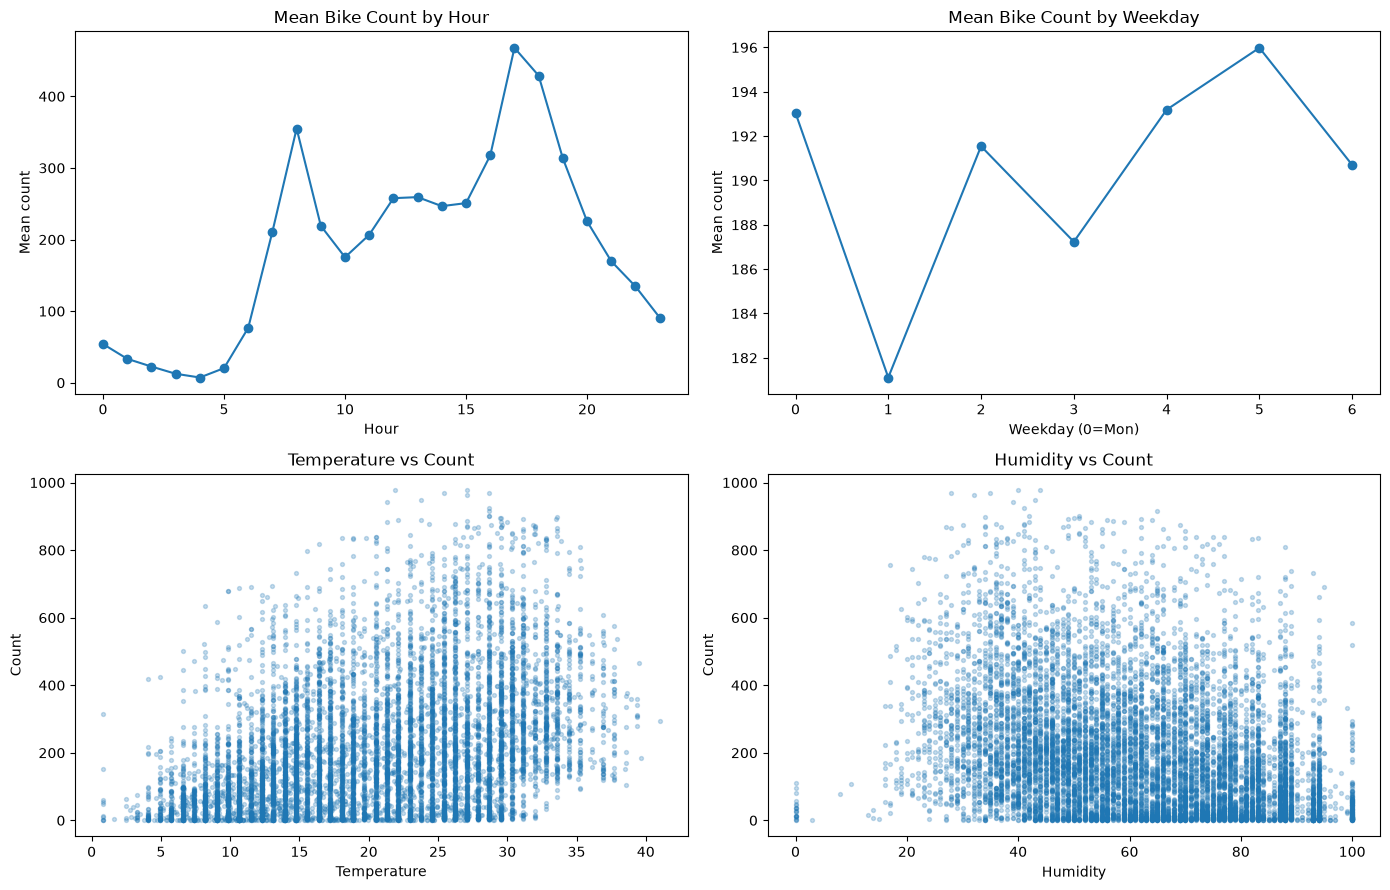

Q2 answer: Hour shows a strong non-linear relationship with demand; temperature also tends to relate positively
to demand, while high humidity/weather conditions can be associated with lower demand.


In [4]:
# Q2. Visualize relationships between key features and count

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

train.groupby("hour")["count"].mean().plot(ax=axes[0,0], marker="o")
axes[0,0].set_title("Mean Bike Count by Hour")
axes[0,0].set_xlabel("Hour")
axes[0,0].set_ylabel("Mean count")

train.groupby("weekday")["count"].mean().plot(ax=axes[0,1], marker="o")
axes[0,1].set_title("Mean Bike Count by Weekday")
axes[0,1].set_xlabel("Weekday (0=Mon)")
axes[0,1].set_ylabel("Mean count")

axes[1,0].scatter(train["temp"], train["count"], s=8, alpha=0.25)
axes[1,0].set_title("Temperature vs Count")
axes[1,0].set_xlabel("Temperature")
axes[1,0].set_ylabel("Count")

axes[1,1].scatter(train["humidity"], train["count"], s=8, alpha=0.25)
axes[1,1].set_title("Humidity vs Count")
axes[1,1].set_xlabel("Humidity")
axes[1,1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print("Q2 answer: Hour shows a strong non-linear relationship with demand; temperature also tends to relate positively")
print("to demand, while high humidity/weather conditions can be associated with lower demand.")


In [5]:
# Q3. Variables likely to be most informative

print("Q3 answer:")
print("1. hour – captures strong commuting/leisure demand patterns during the day.")
print("2. year – captures long-term growth in bike usage.")
print("3. workingday – distinguishes workday commuting patterns from non-working days.")
print("4. weekday – captures weekly demand patterns.")
print("5. month/season – captures seasonal changes.")
print("6. weather and humidity – reflect conditions affecting willingness to rent bikes.")
print("7. temp/atemp – represent thermal comfort and are likely related to demand.")
print("8. windspeed – may influence riding conditions, although its effect may be weaker.")


Q3 answer:
1. hour – captures strong commuting/leisure demand patterns during the day.
2. year – captures long-term growth in bike usage.
3. workingday – distinguishes workday commuting patterns from non-working days.
4. weekday – captures weekly demand patterns.
5. month/season – captures seasonal changes.
6. weather and humidity – reflect conditions affecting willingness to rent bikes.
7. temp/atemp – represent thermal comfort and are likely related to demand.
8. windspeed – may influence riding conditions, although its effect may be weaker.


In [6]:
# Prepare modelling data

# casual and registered are deliberately excluded: count = casual + registered, so using them would leak the target.
feature_columns = [
    "season", "holiday", "workingday", "weather",
    "temp", "atemp", "humidity", "windspeed",
    "year", "month", "hour", "weekday", "day", "dayofyear",
    "weekofyear", "hour_sin", "hour_cos", "weekday_sin", "weekday_cos",
    "month_sin", "month_cos", "rush_hour"
]

categorical_features = [
    "season", "holiday", "workingday", "weather",
    "year", "month", "hour", "weekday", "rush_hour"
]
numeric_features = [c for c in feature_columns if c not in categorical_features]

X = train[feature_columns]
y = train["count"].astype(float)

# Chronological 80/20 split: validation contains later observations and avoids random mixing of future/past rows.
split_index = int(len(train) * 0.80)
X_fit, X_valid = X.iloc[:split_index], X.iloc[split_index:]
y_fit, y_valid = y.iloc[:split_index], y.iloc[split_index:]

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("num", StandardScaler(), numeric_features)
])

def rmsle(y_true, y_pred):
    y_pred = np.maximum(np.asarray(y_pred), 0)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

print("Training rows:", len(X_fit))
print("Validation rows:", len(X_valid))


Training rows: 8360
Validation rows: 2090


In [7]:
# Q5. Simple Linear Regression

linear_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])

linear_pipeline.fit(X_fit, np.log1p(y_fit))
linear_pred = np.maximum(np.expm1(linear_pipeline.predict(X_valid)), 0)
linear_score = rmsle(y_valid, linear_pred)

print("Q5: Linear Regression validation RMSLE =", round(linear_score, 5))
print("The model is trained on log1p(count), which is consistent with the RMSLE evaluation scale.")


Q5: Linear Regression validation RMSLE = 0.62233
The model is trained on log1p(count), which is consistent with the RMSLE evaluation scale.


In [8]:
# Q6. Ridge and Lasso on the engineered feature space

model_specs = {
    "Linear Regression": LinearRegression(),
    "Ridge alpha=0.1": Ridge(alpha=0.1),
    "Ridge alpha=1": Ridge(alpha=1.0),
    "Ridge alpha=10": Ridge(alpha=10.0),
    "Ridge alpha=100": Ridge(alpha=100.0),
    "Lasso alpha=0.0001": Lasso(alpha=0.0001, max_iter=30000),
    "Lasso alpha=0.001": Lasso(alpha=0.001, max_iter=30000),
}

results = []
fitted_models = {}

for name, estimator in model_specs.items():
    pipe = Pipeline([("preprocess", preprocessor), ("model", estimator)])
    pipe.fit(X_fit, np.log1p(y_fit))
    pred = np.maximum(np.expm1(pipe.predict(X_valid)), 0)
    score = rmsle(y_valid, pred)
    results.append({"Model": name, "RMSLE": score})
    fitted_models[name] = pipe

# Degree-2 polynomial features for continuous engineered variables, followed by Ridge.
poly_numeric_features = [
    "temp", "atemp", "humidity", "windspeed",
    "hour_sin", "hour_cos", "weekday_sin", "weekday_cos",
    "month_sin", "month_cos"
]

poly_preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("poly_num", Pipeline([
        ("scale", StandardScaler()),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("scale_poly", StandardScaler())
    ]), poly_numeric_features),
    ("other_num", StandardScaler(), ["day", "dayofyear", "weekofyear"])
])

for alpha in [1.0, 10.0, 100.0]:
    name = f"Polynomial degree 2 + Ridge alpha={alpha:g}"
    pipe = Pipeline([
        ("preprocess", poly_preprocessor),
        ("model", Ridge(alpha=alpha))
    ])
    pipe.fit(X_fit, np.log1p(y_fit))
    pred = np.maximum(np.expm1(pipe.predict(X_valid)), 0)
    score = rmsle(y_valid, pred)
    results.append({"Model": name, "RMSLE": score})
    fitted_models[name] = pipe

results_table = pd.DataFrame(results).sort_values("RMSLE").reset_index(drop=True)

print("Q6: Models tried and validation scores")
print(results_table.to_string(index=False))


Q6: Models tried and validation scores
                                Model    RMSLE
 Polynomial degree 2 + Ridge alpha=10 0.610267
  Polynomial degree 2 + Ridge alpha=1 0.610312
Polynomial degree 2 + Ridge alpha=100 0.612911
                       Ridge alpha=10 0.621820
                   Lasso alpha=0.0001 0.622135
                    Lasso alpha=0.001 0.622145
                        Ridge alpha=1 0.622145
                      Ridge alpha=0.1 0.622199
                    Linear Regression 0.622326
                      Ridge alpha=100 0.629988


In [9]:
# Q7. Model comparison and interpretation

results_table["Observation"] = results_table["Model"].map({
    "Linear Regression": "Strong baseline; one-hot time features capture nonlinearity.",
    "Ridge alpha=0.1": "Small regularization; stabilizes correlated features.",
    "Ridge alpha=1": "Moderate regularization.",
    "Ridge alpha=10": "Stronger shrinkage; tests bias/variance trade-off.",
    "Ridge alpha=100": "Very strong shrinkage; may underfit.",
    "Lasso alpha=0.0001": "Sparse regularization with small penalty.",
    "Lasso alpha=0.001": "More coefficient shrinkage/sparsity.",
    "Polynomial degree 2 + Ridge alpha=1": "Adds pairwise nonlinear numeric effects with Ridge regularization.",
    "Polynomial degree 2 + Ridge alpha=10": "Polynomial effects with stronger regularization.",
    "Polynomial degree 2 + Ridge alpha=100": "Heavy regularization of polynomial expansion."
})

print("Q7 final comparison table:")
display(results_table)

best_name = results_table.loc[0, "Model"]
best_pipeline = fitted_models[best_name]
best_valid_pred = np.maximum(np.expm1(best_pipeline.predict(X_valid)), 0)

print("Best validation model:", best_name)
print("Best validation RMSLE:", round(results_table.loc[0, "RMSLE"], 5))


Q7 final comparison table:


,Model,RMSLE,Observation
0,Polynomial degree 2 + Ridge alpha=10,0.610267,Polynomial effects with stronger regularization.
1,Polynomial degree 2 + Ridge alpha=1,0.610312,Adds pairwise nonlinear numeric effects with R...
2,Polynomial degree 2 + Ridge alpha=100,0.612911,Heavy regularization of polynomial expansion.
3,Ridge alpha=10,0.621820,Stronger shrinkage; tests bias/variance trade-...
4,Lasso alpha=0.0001,0.622135,Sparse regularization with small penalty.
5,Lasso alpha=0.001,0.622145,More coefficient shrinkage/sparsity.
6,Ridge alpha=1,0.622145,Moderate regularization.
7,Ridge alpha=0.1,0.622199,Small regularization; stabilizes correlated fe...
8,Linear Regression,0.622326,Strong baseline; one-hot time features capture...
9,Ridge alpha=100,0.629988,Very strong shrinkage; may underfit.


Best validation model: Polynomial degree 2 + Ridge alpha=10
Best validation RMSLE: 0.61027


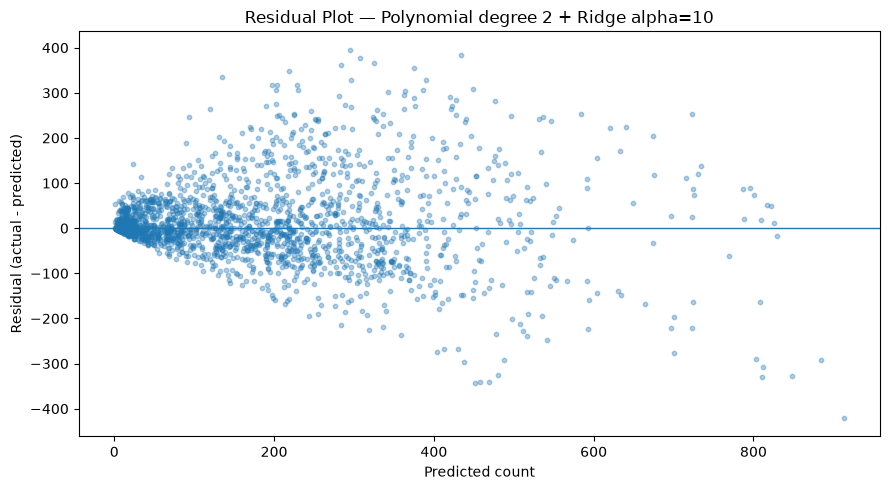

Q8 answer: The residual plot is used to check whether errors are centered around zero and whether
there is a strong systematic pattern or changing variance. Some spread is expected because bike demand
is affected by additional factors not represented in the available features.


In [10]:
# Q8. Residual plot for the best model

residuals = y_valid.to_numpy() - best_valid_pred

plt.figure(figsize=(9, 5))
plt.scatter(best_valid_pred, residuals, s=10, alpha=0.35)
plt.axhline(0, linewidth=1)
plt.xlabel("Predicted count")
plt.ylabel("Residual (actual - predicted)")
plt.title(f"Residual Plot — {best_name}")
plt.tight_layout()
plt.show()

print("Q8 answer: The residual plot is used to check whether errors are centered around zero and whether")
print("there is a strong systematic pattern or changing variance. Some spread is expected because bike demand")
print("is affected by additional factors not represented in the available features.")


## Written Answers: Q9–Q12

### Q9. Why does the winning model perform better?

The winning model combines time-derived features, weather variables and categorical encodings, allowing it to represent recurring demand patterns that a basic linear relationship cannot represent well. The degree-2 polynomial version can additionally represent nonlinear interactions among selected continuous/weather features. Ridge regularization controls the size of coefficients introduced by correlated and expanded features, reducing overfitting. Training on `log1p(count)` also puts the model on the logarithmic scale used by RMSLE.

### Q10. Why does RMSLE penalize under-predictions more gently than RMSE?

RMSLE first applies a logarithm, so it measures errors largely in **relative/proportional terms** rather than raw count differences. This reduces the influence of very large absolute errors. It is more accurate to say that RMSLE is less sensitive to absolute magnitude than RMSE; it does **not** inherently make an equally sized multiplicative under-prediction cheaper than the corresponding over-prediction. For example, predicting half the true value and predicting twice the true value have equal log-distance apart from the `+1` adjustment.

### Q11. What are the trade-offs between model simplicity and predictive power?

A simple Linear Regression model is fast, interpretable and easy to maintain, but it can underfit nonlinear relationships. Polynomial features and regularization can improve predictive performance, but they increase model complexity, computation and the need for tuning. A more complex model should therefore be preferred only when its validation performance improves enough to justify that additional complexity.

### Q12. Why can't Linear Regression alone capture time-of-day effects effectively?

If `hour` is treated as one ordinary numeric variable, Linear Regression assumes a single straight-line relationship between hour and demand. Bike demand does not behave this way: it can have morning and evening peaks, low demand overnight, and a different pattern on working days. One-hot encoding of `hour`, cyclic features, and interaction/nonlinear features allow the model to represent these patterns much more effectively.


In [11]:
# Final model and submission.csv

# Refit the selected validation winner on all labelled training data.
best_final = fitted_models[best_name]
best_final.fit(X, np.log1p(y))

test_pred = np.maximum(np.expm1(best_final.predict(test[feature_columns])), 0)

submission = pd.DataFrame({
    "datetime": raw_test_datetime,
    "count_predicted": test_pred
})

submission_path = "submission.csv"
submission.to_csv(submission_path, index=False)

print("Submission created:", submission_path)
print("Submission shape:", submission.shape)
print("Columns:", list(submission.columns))
print("Expected rows:", len(test_raw))
print("Actual rows:", len(submission))
print("Missing values:", int(submission.isna().sum().sum()))
print("All predictions numeric:", pd.api.types.is_numeric_dtype(submission["count_predicted"]))
print("\nFirst five rows:")
print(submission.head())


Submission created: submission.csv
Submission shape: (2613, 2)
Columns: ['datetime', 'count_predicted']
Expected rows: 2613
Actual rows: 2613
Missing values: 0
All predictions numeric: True

First five rows:
           datetime  count_predicted
0   05-06-2012 5:00        14.428469
1  19-03-2011 19:00       186.033256
2   02-04-2012 6:00        48.231620
3  13-07-2012 20:00       443.982273
4  09-11-2011 19:00       240.222780


In [12]:
# Final verification checklist

assert list(submission.columns) == ["datetime", "count_predicted"]
assert len(submission) == len(test_raw)
assert submission["datetime"].equals(test_raw["datetime"])
assert submission["count_predicted"].notna().all()
assert np.isfinite(submission["count_predicted"]).all()
assert (submission["count_predicted"] >= 0).all()

print("PASS: exactly 2 columns")
print("PASS: row count matches bike_test.csv")
print("PASS: datetime ordering/values preserved")
print("PASS: no missing predictions")
print("PASS: all predictions are numeric and non-negative")
print("Ready for submission.csv.")


PASS: exactly 2 columns
PASS: row count matches bike_test.csv
PASS: datetime ordering/values preserved
PASS: no missing predictions
PASS: all predictions are numeric and non-negative
Ready for submission.csv.


## Submission Checklist

For Taxila, submiting:

1. **Executed `.ipynb` notebook** containing code, outputs, plots and answers Q1–Q12.
2. **`submission.csv`** containing exactly:
   - `datetime`
   - `count_predicted`
3. **Screenshot/proof of successful execution on the BITS Lab portal. attached into dir in pdf: 
   >>2026AJ05347_MLAssignment1_notebookrunScreenshot.pdf**
4. Placed the notebook, `submission.csv`, and screenshot into one ZIP file.
